<a href="https://colab.research.google.com/github/Kellia855/linear_regression_model/blob/main/multivariate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regression Analysis: Predicting Blood Glucose Level for Diabetes Risk Screening
**Mission context:** Elevated blood glucose is the primary clinical marker used to diagnose and flag diabetes risk. Rather than predicting the binary `Outcome` label directly (a classification problem), this notebook builds a **regression model that predicts a patient's glucose level** from other routine health metrics (BMI, age, blood pressure, pregnancies, insulin, pedigree function, and existing diagnosis status).



### Importing Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

pd.set_option('display.max_columns', None)
print("Libraries loaded")




Libraries loaded


### Data Loading

In [6]:
df = pd.read_csv("Healthcare-Diabetes.csv")
df = df.drop(columns=["Id"], errors="ignore")
print("Shape", df.shape)
df.head()

Shape (2768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2768 entries, 0 to 2767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2768 non-null   int64  
 1   Glucose                   2768 non-null   int64  
 2   BloodPressure             2768 non-null   int64  
 3   SkinThickness             2768 non-null   int64  
 4   Insulin                   2768 non-null   int64  
 5   BMI                       2768 non-null   float64
 6   DiabetesPedigreeFunction  2768 non-null   float64
 7   Age                       2768 non-null   int64  
 8   Outcome                   2768 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 194.8 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000
mean,3.742775,121.102601,69.134393,20.824422,80.127890,32.137392,0.471193,33.132225,0.343931
std,3.323801,32.036508,19.231438,16.059596,112.301933,8.076127,0.325669,11.777230,0.475104
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.244000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,37.000000,32.200000,0.375000,29.000000,0.000000
75%,6.000000,141.000000,80.000000,32.000000,130.000000,36.625000,0.624000,40.000000,1.000000
max,17.000000,199.000000,122.000000,110.000000,846.000000,80.600000,2.420000,81.000000,1.000000


### Data Cleaning

In [9]:
df.isnull().sum()


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [10]:
df.duplicated().sum()

np.int64(1990)

In [11]:
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (778, 9)


In [12]:
cols_with_fake_zeros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
print("Zero counts (disguised missing values) before cleaning:")
for c in cols_with_fake_zeros:
    print(f"  {c}: {(df[c] == 0).sum()} zeros out of {len(df)} rows")

Zero counts (disguised missing values) before cleaning:
  Glucose: 5 zeros out of 778 rows
  BloodPressure: 36 zeros out of 778 rows
  SkinThickness: 229 zeros out of 778 rows
  Insulin: 377 zeros out of 778 rows
  BMI: 11 zeros out of 778 rows


In [13]:
df[cols_with_fake_zeros] = df[cols_with_fake_zeros].replace(0, np.nan)
df[cols_with_fake_zeros] = df.groupby("Outcome")[cols_with_fake_zeros].transform(lambda x: x.fillna(x.median()))

print("Zero/NaN counts after cleaning:")
for c in cols_with_fake_zeros:
    print(f"  {c}: zeros={ (df[c]==0).sum() }, nulls={ df[c].isnull().sum() }")


Zero/NaN counts after cleaning:
  Glucose: zeros=0, nulls=0
  BloodPressure: zeros=0, nulls=0
  SkinThickness: zeros=0, nulls=0
  Insulin: zeros=0, nulls=0
  BMI: zeros=0, nulls=0


### Exploratory Data Analysis
This is to visualize distributions and correlations using the cleaned data to identify which features are most worth including in the model.

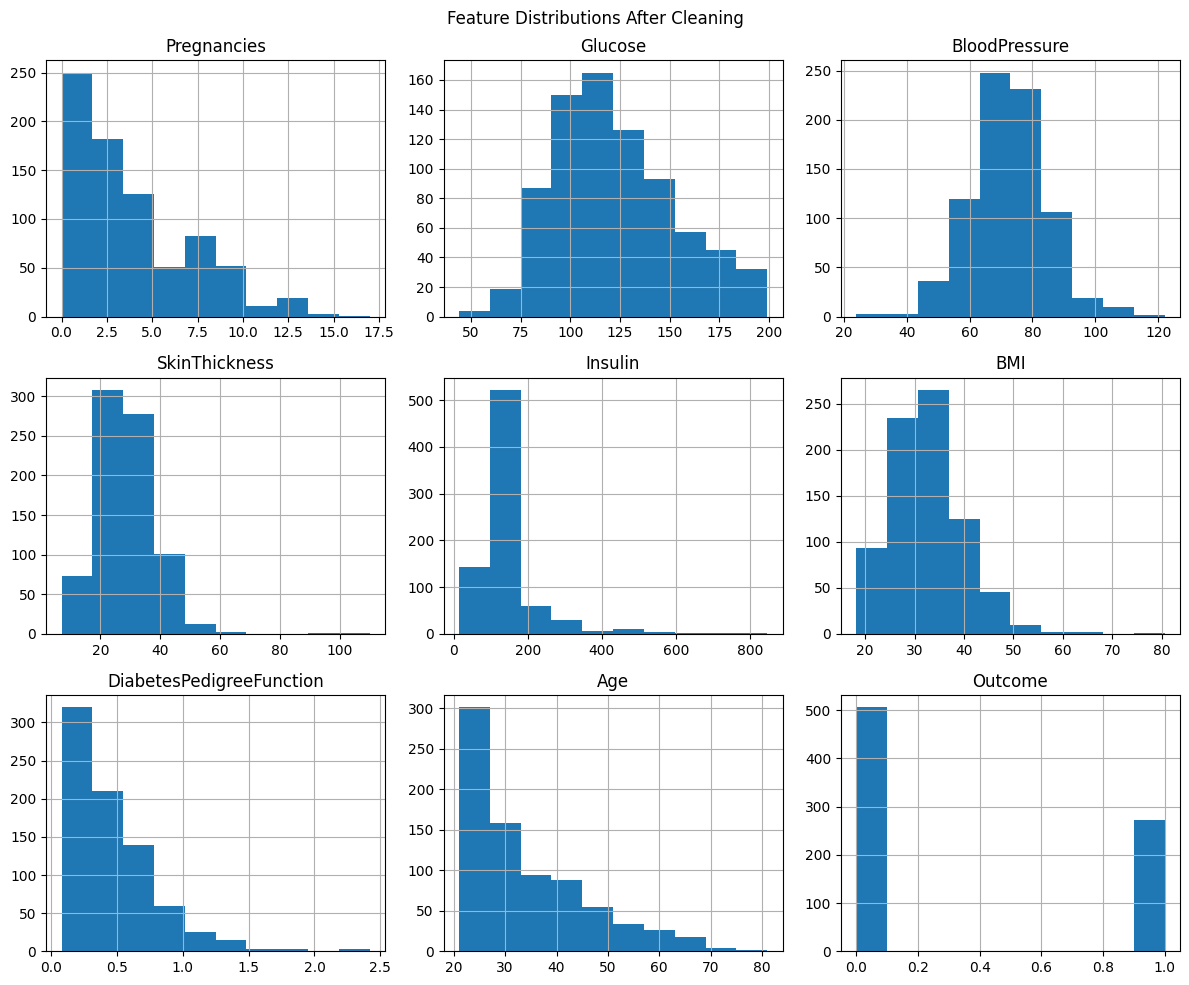

In [14]:
df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions After Cleaning")
plt.tight_layout()
plt.show()

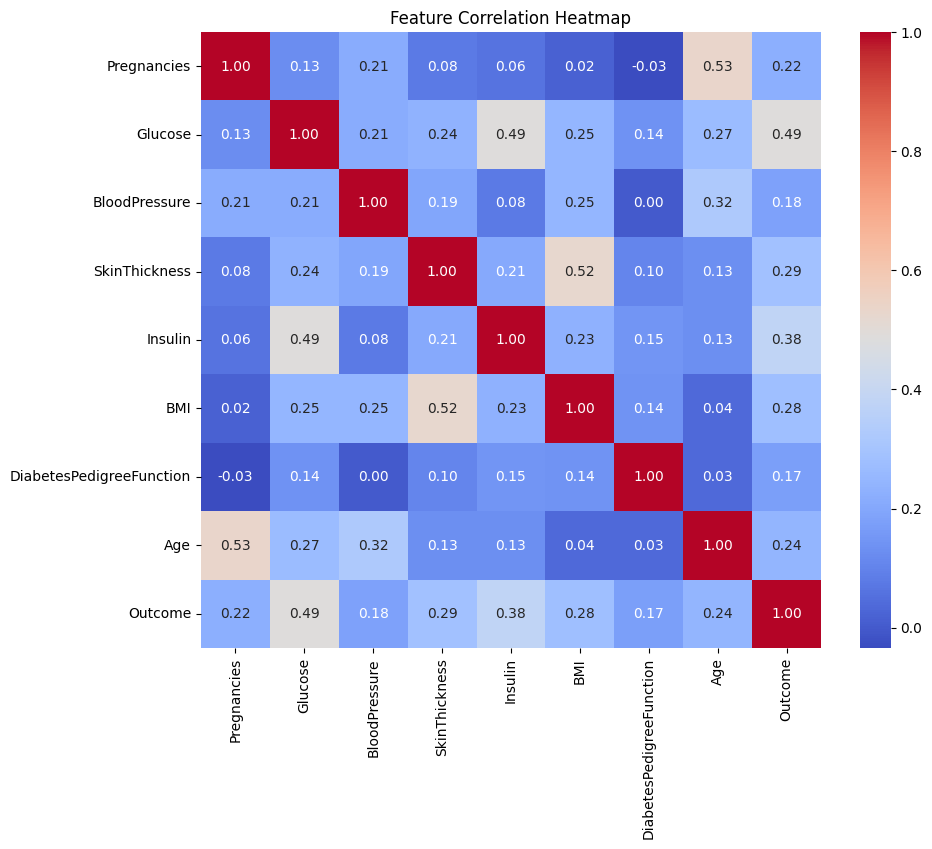

In [18]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

**Interpretation:**

- After cleaning, distributions for `Glucose`, `BloodPressure` and `BMI` are now unimodal and centered around realistic physiological ranges instead of showing an artificial spike at zero.
- Looking at correlations with the target, `Glucose`: `Insulin` and `Age` show the strongest relationships with `BMI`, `Outcome` and `Pregnancies` contributing moderately. `SkinThickness` and `DiabetesPedigreeFunction` correlate weakly with Glucose specifically which i account for in feature selection below.
- `Outcome` (diabetes diagnosis) correlates with `Glucose` at a moderate level, which supports my framing: glucose level is a meaningful proxy for diabetes risk, consistent with clinical practice.

### Feature Engineering
**Target:** `Glucose` — chosen because it's a genuinely continuous variable (unlike `Outcome`) and clinically it is the key marker used to diagnose and monitor diabetes risk.

**Features selected:** `BMI`, `Age`, `BloodPressure`, `Pregnancies`, `Insulin`, `DiabetesPedigreeFunction`, `Outcome`.

**Features dropped:** `SkinThickness` — it showed a weak correlation with Glucose specifically (as opposed to with Insulin where it's more relevant) and skin-fold caliper measurements are also the least reliably collected field in this dataset in practice, so we exclude it to reduce noise.

All features are numeric already so no categorical encoding is needed.


In [19]:
features = ["BMI", "Age", "BloodPressure", "Pregnancies", "Insulin", "DiabetesPedigreeFunction", "Outcome"]
target = "Glucose"

X = df[features]
y = df[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (622, 7)  Test shape: (156, 7)


## Regression Model Comparison

We compare four regression algorithms on the same standardized features and train/test split:

- **Linear Regression** — baseline, closed-form ordinary least squares.
- **Ridge Regression** — adds L2 regularization to reduce overfitting from correlated features (e.g. Insulin and BMI).
- **Lasso Regression** — adds L1 regularization, which can shrink less useful feature coefficients to exactly zero (built-in feature selection).
- **Stochastic Gradient Descent (SGD) Regression** — an iterative optimization approach, useful for comparing against the closed-form solutions above and as the basis for our gradient descent analysis below.

We evaluate each with Mean Squared Error (MSE) and R² on the held-out test set.

In [21]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "SGDRegressor": SGDRegressor(max_iter=1000, tol=1e-3, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results[name] = {"mse": mse, "r2": r2, "model": model}
    print(f"{name:18s}  MSE = {mse:8.3f}   R2 = {r2:.3f}")


LinearRegression    MSE =  573.045   R2 = 0.297
Ridge               MSE =  572.920   R2 = 0.298
Lasso               MSE =  573.499   R2 = 0.297
SGDRegressor        MSE =  573.612   R2 = 0.297


**Interpretation:** All four models land in a similar range (R² ≈ 0.29–0.30), which tells us the linear relationship between these features and Glucose is real but moderate — glucose level depends on many physiological factors beyond what's captured here. Ridge performs marginally best, suggesting a small amount of regularization helps slightly, likely due to mild correlation between features like BMI and Insulin.

### Gradient Descent Optimization
Here we specifically optimize an `SGDRegressor` using iterative gradient descent (`partial_fit` in a loop, rather than a single `fit` call), so we can track how training and test loss (MSE) evolve across epochs. This is the "loss curve" required by the assignment — it lets us check for overfitting (test loss rising while train loss keeps falling) or underfitting (both losses staying high and flat).

In [20]:
sgd_gd = SGDRegressor(
    max_iter=1, tol=None, warm_start=True, random_state=42,
    learning_rate="invscaling", eta0=0.01
)

n_epochs = 100
train_losses, test_losses = [], []

for epoch in range(n_epochs):
    sgd_gd.partial_fit(X_train, y_train)
    train_pred = sgd_gd.predict(X_train)
    test_pred = sgd_gd.predict(X_test)
    train_losses.append(mean_squared_error(y_train, train_pred))
    test_losses.append(mean_squared_error(y_test, test_pred))

print(f"Final train loss (MSE): {train_losses[-1]:.3f}")
print(f"Final test loss  (MSE): {test_losses[-1]:.3f}")


Final train loss (MSE): 579.790
Final test loss  (MSE): 574.110


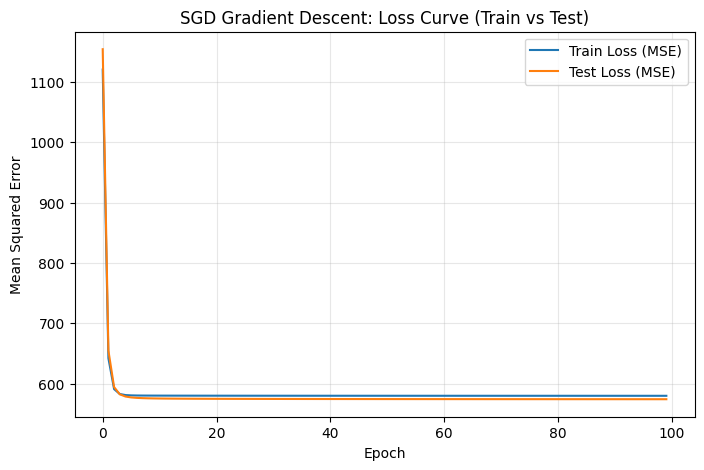

In [22]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss (MSE)")
plt.plot(test_losses, label="Test Loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("SGD Gradient Descent: Loss Curve (Train vs Test)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Interpretation:** Train and test loss converge to nearly the same value and flatten out after roughly 20–30 epochs, with no divergence between the two curves. This indicates the model is **not overfitting** — but the plateau itself, at a relatively high MSE, indicates **underfitting**: the model has reached the limit of what a linear relationship with these features can explain about Glucose. Further loss reduction would likely require non-linear models, additional features, or more data — not more training iterations.


## Scatter Plots: Before and After
**Before:** raw `BMI` vs. `Glucose` with a simple fitted line, showing the linear relationship the model is trying to capture in a single feature (before standardization/multivariate modeling).

**After:** predicted vs. actual `Glucose` values on the test set for the best-performing model, where points falling closer to the diagonal line indicate more accurate predictions.

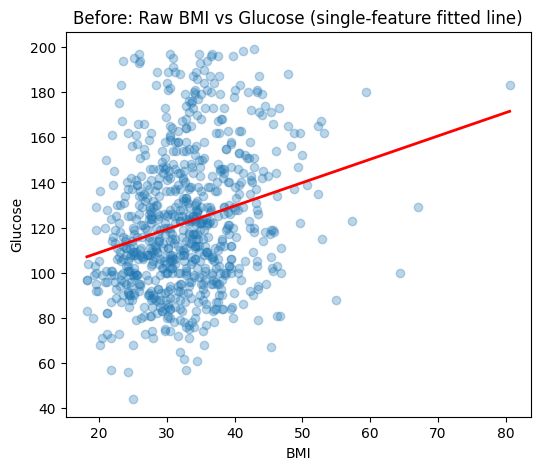

In [23]:
plt.figure(figsize=(6,5))
plt.scatter(df["BMI"], df["Glucose"], alpha=0.3)
z = np.polyfit(df["BMI"], df["Glucose"], 1)
p = np.poly1d(z)
xs = np.linspace(df["BMI"].min(), df["BMI"].max(), 100)
plt.plot(xs, p(xs), color="red", linewidth=2)
plt.xlabel("BMI")
plt.ylabel("Glucose")
plt.title("Before: Raw BMI vs Glucose (single-feature fitted line)")
plt.show()


Best-performing model: Ridge


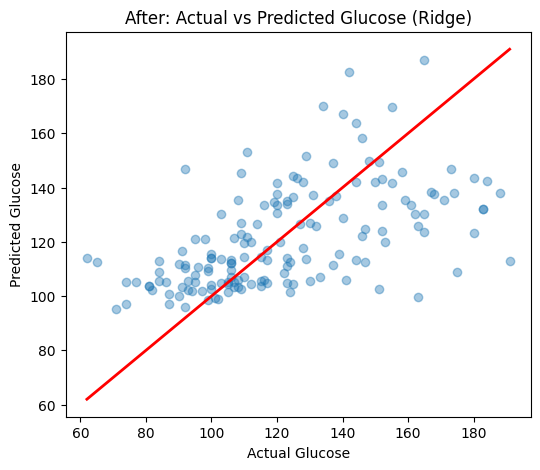

In [24]:
best_name = min(results, key=lambda k: results[k]["mse"])
best_model = results[best_name]["model"]
print("Best-performing model:", best_name)

preds_best = best_model.predict(X_test)

plt.figure(figsize=(6,5))
plt.scatter(y_test, preds_best, alpha=0.4)
lims = [min(y_test.min(), preds_best.min()), max(y_test.max(), preds_best.max())]
plt.plot(lims, lims, color="red", linewidth=2)
plt.xlabel("Actual Glucose")
plt.ylabel("Predicted Glucose")
plt.title(f"After: Actual vs Predicted Glucose ({best_name})")
plt.show()


**Interpretation:** The "before" plot shows a weak but visible positive linear trend between BMI and Glucose alone. The "after" plot (multivariate best model) shows predictions clustering loosely around the diagonal — better than any single feature alone, but with clear spread, consistent with the moderate R² we saw earlier.


## Save the Best-Performing Model
We bundle the trained model together with the `StandardScaler` and the exact feature list into a single `joblib` file.

In [25]:
bundle = {
    "model": best_model,
    "scaler": scaler,
    "features": features,
    "target": target,
}
joblib.dump(bundle, "best_glucose_model.pkl")
print(f"Saved best model ({best_name}) to best_glucose_model.pkl")


Saved best model (Ridge) to best_glucose_model.pkl


## Prediction Script (for Task 2)

This function loads the saved model bundle and makes a single prediction from a dictionary of raw input values, in the exact order/format the FastAPI endpoint in Task 2 will need to replicate. This is the function Task 2 wraps in an API.

In [26]:
def predict_glucose(input_dict):
    """Predict blood glucose level from raw (unscaled) patient metrics.

    input_dict keys required: BMI, Age, BloodPressure, Pregnancies,
    Insulin, DiabetesPedigreeFunction, Outcome
    """
    loaded = joblib.load("best_glucose_model.pkl")
    x = pd.DataFrame([input_dict])[loaded["features"]]
    x_scaled = loaded["scaler"].transform(x)
    prediction = loaded["model"].predict(x_scaled)[0]
    return float(prediction)

# Example usage
sample_patient = {
    "BMI": 28.5,
    "Age": 35,
    "BloodPressure": 72,
    "Pregnancies": 2,
    "Insulin": 130,
    "DiabetesPedigreeFunction": 0.5,
    "Outcome": 0,
}

predicted_glucose = predict_glucose(sample_patient)
print(f"Predicted glucose level: {predicted_glucose:.1f} mg/dL")
if predicted_glucose >= 140:
    print("Risk flag: ELEVATED (>= 140 mg/dL, pre-diabetic/diabetic range)")
else:
    print("Risk flag: NORMAL range")


Predicted glucose level: 114.6 mg/dL
Risk flag: NORMAL range
